# Technische Universität Braunschweig - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Technische Universität Braunschweig' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/010nsgg66' -- 'Technische Universität Braunschweig'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W4281706753
1,not assigned,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W4281706753
2,not assigned,Technische Universität Braunschweig,"Division of Molecular Cell Biology, Zoological...",https://openalex.org/W4280623252
3,not assigned,Technische Universität Braunschweig,Helmholtz Institute for Pharmaceutical Researc...,https://openalex.org/W4309197690
4,not assigned,Technische Universität Braunschweig,"Institut für Mathematische Physik, Technische ...",https://openalex.org/W4285800153


In [459]:
MAPPING_DICT = {
    'Braunschweig Integrated Centre of Systems Biology (BRICS)': ['(brics)', 'systems biology'],
    'Carl-Friedrich-Gauß-Fakultät': ['reichertz', 'algebra', 'equations', 'differentialgleichungen', '(automotive|information) management', 'numerical mathematics',
                                     'public policy', 'scientific computing', 'soziologie', 'operating systems', 'computer science', 'wirtschaftsinformatik',
                                     'medical informatics', 'mathematical optimization', 'graphi(k|cs)', 'roboti(k|cs)', 'stochasti(k|cs)', 'application security',
                                     'industrial production', 'numerical', 'finance', 'economics', 'enterprise', '(department|institute) of mathematics', 'communication science',
                                     'international(e)? (relations|beziehungen)', 'sociology', 'dienstleistungsmanagement', 'information systems', 'software engineering',
                                     'unternehmensführung', 'chip design', 'computational (science|mathematics)', 'volkswirtschaftslehre'
                                    ],
    'Carolo-Wilhelmina-Forschungszentren': ['metrolog(ie|y)', 'carolo-wilhelmina'],
    'Fakultät Architektur, Bauingenieurwesen und Umweltwissenschaften': ['geod(äsie|esy)', 'geo(chemie|technik|ecology)', 'wood(-|‐)based (construction|materials)', 
                                                                         'construction (design|management)',
                                                                         '(steel|timber) structures', 'civil engineering', 'geosystems', '(solid|concrete) construction',
                                                                         'water resources', '(wasser|holz|massiv|stahl)bau', 'landscape ecology', 'architecture',
                                                                         'tragwerksentwurf', 'applied mechanics', 'urban(?!e\swissen)', 'design research',
                                                                         'statik', 'materials science', 'geosysteme', 'hydrology', 'geoökologie',
                                                                         'hydraulic engineering', 'structural (analysis|design)', 'sanitary', 'railway', 
                                                                         'bau(wirtschaft|werkserhaltung)', 'waste', 'pavement'
                                                                        ],
    'Fakultät für Elektrotechnik, Informationstechnik, Physik': ['(theoretische|mathematische|angewandte) physik', 'geophysi(k|cs)', 'electromagnetic', 'high voltage',
                                                                 'semiconductor', '(ifn)', 'electrical machines', '(control|network|electrical) engineering',
                                                                 'communication(s)? (technology|network)', 'halbleitertechnik', 'kondensierten materie',
                                                                 'cmos(,| design)', '(applied|theoretical|mathematical|matter) physic(s)?', 'datentechnik',
                                                                 'hochfrequenztechnik', 'elektrotechnik', 'hochspannungstechnik', 'high(-|\s)frequency(\smeas.)? techn(ik|ology)',
                                                                 'nachrichtentechnik', 'photonic', 'emc,', 'information theory' 
                                                                ],
    'Fakultät für Geistes- und Erziehungswissenschaften': ['sport(s)? science', 'fachdidaktik', '(german|american) studies', 'geschichtswissenschaft', 'education',
                                                           'philosophy', 'erziehungswissenschaft', 'bewegungspädagogik', 'germanistik', 'pädagogische',
                                                           'historisches seminar', 'english linguistics', 'sprachwissenschaft', 'theolog(ie|y)'
                                                          ],
    'Fakultät für Lebenswissenschaften': ['pharma(?!verfahrenstechnik)', 'neurobiology', 'psychotherap(ie|y)', 'zoological', 'plant biology', 
                                          '(theoretische|organische|analytische|technische) chemie', '(physical|analytical|theoretical|technical|organic|sustainable) chemistry', 
                                          '(institut(e)?|department) (of|f(ü)?r|for|fuer) psycholog(ie|y)',
                                          'food chemistry', 'bioinformatics', 'mi(k|c)robiolog(ie|y)', 'lebensmittelchemie', 'biotechnolog(ie|y)', 'geneti(k|cs)',
                                          'electrocatalysis', 'social psychology', 'zoologische(s)?', 'klinische psychologie', 'life sciences', 'sociotechnical',
                                          '(engineering|traffic) psychology', '(sozial|verkehrs)psychologie', 'pflanzenbiologie', 'physiology', 'biochemistry'
                                         ],
    'Fakultät für Maschinenbau': ['thermal (process|engineering)', 'turbomachinery', 'dynamics and vibrations', 'werkzeugmaschinen', 'joining', 'machine tools',
                                  'fluid (mechanics|dynamics)', 'aerospace', 'a(k|co)usti(k|cs)', 'aviation', 'particle(s)? technology', 'institut für werkstoffe',
                                  'biochemical engineering', 'process systems engineering', 'engineering design', '(mechanical|automotive) engineering', 'adaptroni(k|cs)',
                                  'logistic(s)? systems', 'aircraft', '(schweiß|partikel)technik', 'mi(k|c)ro(\s)?tech(n)?(ik|ology)', 
                                  'flight guidance', 'flugf(ü|u)hrung',
                                  'space systems', 'maschinenbau', '(surface|automotive) technology', 'str(o|ö)mungs(maschinen|mechanik)', 'thermodynami(k|cs)',
                                  '(produktionsmess|konstruktions)techni(c)?k', 'vehicle drives', 'production measurement', 'flugzeugbau', 'thermische verfahrenstechnik',
                                  'dynamik und schwingungen', 'verbrennungskraftmaschinen', '(iprom)', 'intermodal'
                                 ],
    'Niedersächsisches Forschungszentrum Fahrzeugtechnik (NFF)': ['center for automotive'],
    #'Niedersächsisches Forschungszentrum für Luftfahrt (NFL)': [],
    'Universitätsbibliothek': ['universitätsbibliothek'],
    #'Zentrale Einrichtung Botanischer Garten': [],
    'Battery Labfactory Braunschweig': ['battery lab(\s)?factory'], # selbst ergänzt
}

In [460]:
with open('./mapping_tables_fak/tubraunschweig.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [461]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [462]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [463]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W4281706753
1,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W4281706753
2,Fakultät für Lebenswissenschaften,Technische Universität Braunschweig,"Division of Molecular Cell Biology, Zoological...",https://openalex.org/W4280623252
3,Fakultät für Lebenswissenschaften,Technische Universität Braunschweig,Helmholtz Institute for Pharmaceutical Researc...,https://openalex.org/W4309197690
4,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,"Institut für Mathematische Physik, Technische ...",https://openalex.org/W4285800153
...,...,...,...,...
13570,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3135134609
13571,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3136803478
13572,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W4386866658
13573,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3170076571


In [464]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[320:340]

array(['Zentrum für Pharmaverfahrenstechnik (PVZ), Technischen Universität Braunschweig, Franz-Liszt-Str. 35a, 38106, Braunschweig, Germany',
       'University of Brunswick/TU Braunschweig',
       'Technische Universität Braunschweig, Langer Kamp 6, 38106 Brunswick, Germany',
       'Coastal Research Centre, Joint Research Facility of Leibniz Universität Hannover and Technische Universität Braunschweig, Merkurstraße 11, 30419 Hannover, Germany',
       'Technische Universität Braunschweig Deutschland',
       'Forschungszentrum Küste Leibniz Universität Hannover and Technische Universität Braunschweig  Merkurstraße 11 30419 Hannover Germany',
       'Thünen Institute of Market Analysis, Bundesallee 63, 38116, Brunswick, Germany',
       'Technische Universität Braunschweig, Mühlenpfordtstr.\xa023, 38106, Braunschweig, Deutschland',
       'Thünen Institute of Market Analysis, Bundesallee 63, Braunschweig, 38116, Germany',
       'Technische Universität Braunschweig, Institut für Fahr

In [465]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Battery Labfactory Braunschweig,159
1,Braunschweig Integrated Centre of Systems Biol...,432
2,Carl-Friedrich-Gauß-Fakultät,1113
3,Carolo-Wilhelmina-Forschungszentren,363
4,"Fakultät Architektur, Bauingenieurwesen und Um...",1293
5,"Fakultät für Elektrotechnik, Informationstechn...",1749
6,Fakultät für Geistes- und Erziehungswissenscha...,174
7,Fakultät für Lebenswissenschaften,3233
8,Fakultät für Maschinenbau,2517
9,Universitätsbibliothek,11


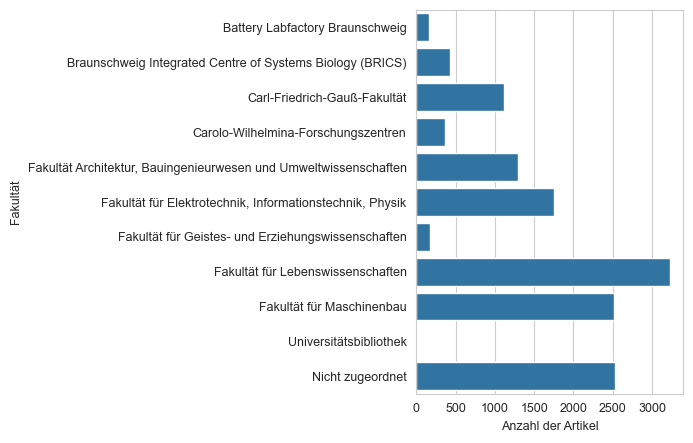

In [466]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [467]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8135543278084715

In [468]:
MAPPING_DICT_DEPT = {
    'Carl-Friedrich-Gauß-Fakultät': {
        'Department für Sozialwissenschaften': ['sozialwissenschaften', 'comparative politics', 'so(z|c)iolog(ie|y)', 'communication science', 'international relations',
                                                'internationale beziehungen'
                                               ],
        'Department Informatik': ['computer(\s)?(science|graphi(k|c)|network)', 'reichertz', 'roboti(k|cs)', 'medical informatics', 'software engineering',
                                  'information systems', '(embedded|scientific) computing', 'application security'
                                 ],
        'Department Mathematik': ['analysis', 'differential', 'mathemati', 'stochastik'],
        'Department Wirtschaftswissenschaften': ['wirtschaftsinformatik', '(information|automotive) management', 'unternehmensführung', 'economics', 'finance',
                                                 'enterprise', 'dienstleistungsmanagement', 'industrial production'
                                                ],
    },
    'Fakultät Architektur, Bauingenieurwesen und Umweltwissenschaften': {
        #'Bet Tfila - Forschungsstelle für jüdische Architektur in Europa': [],
        'Department Architektur': ['design', 'tragwerksentwurf', 'archite(k|c)tur', 'urban'],
        'Department Bauingenieurwesen und Umweltwissenschaften': ['geo(ecology|system|technik|chemie)', 'leich(t)?wei(ß|ss)?', 'building materials', 'steel', 'applied mechanics',
                                                                  'material(s)? (science|building)', 'photogrammetr(ie|y)', 'computational model(l)?ing', 'structural analysis',
                                                                  'timber', 'wood(-|‐)based', 'landscape ecology', '(massiv|holz|stahl)bau', 'statik und dynamik',
                                                                  'bauwirtschaft', 'geoökologie', 'sanitary', 'construction management', 'railway', 'statik',
                                                                  'bauwerkserhaltung', 'hydrolog(ie|y)', 'coastlines', 'hydraulic', 'concrete construction', 'waste'
                                                                 ],
        'Institut für Planung des öffentlichen Verkehrs': ['urban engineering', 'pavement'],
        #'Juniorprofessur Gender.ING': [],
    },
    'Fakultät für Elektrotechnik, Informationstechnik, Physik': {
        'Abteilung für Physik': ['physi(k|c)'],
        'Institut für CMOS Design': ['cmos'],
        'Institut für Datentechnik und Kommunikationsnetze': ['kommunikationsnetze', 'network engineering', 'communication(s)? network'],
        'Institut für Elektrische Maschinen, Antriebe und Bahnen': ['elektrische maschinen', 'electrical machines'],
        'Institut für Elektrische Messtechnik und Grundlagen der Elektrotechnik': ['elektrotechnik', 'electrical measurement'],
        'Institut für Elektromagnetische Verträglichkeit': ['ele(k|c)tromagneti(sch|c)', 'emc,'],
        'Institut für Halbleitertechnik': ['semiconductor', 'halbleiter'],
        'Institut für Hochfrequenztechnik': ['hochfrequenztechnik', 'photonic', 'high(-|\s)frequency'],
        'Institut für Hochspannungstechnik und Energiesysteme - elenia': ['hochspannungstechnik', 'elenia', 'high voltage'],
        'Institut für Nachrichtentechnik': ['nachrichtentechnik', 'commun(.|ication(s)?) technol(.|ogy)', 'information theory'],
        'Institut für Regelungstechnik': ['regelungstechnik', 'control engineering'],
    },
    'Fakultät für Geistes- und Erziehungswissenschaften': {
        'Institut für Anglistik und Amerikanistik': ['english linguistic', 'american studies', 'sprachwissenschaft'],
        'Institut für Didaktik der Mathematik und Elementarmathematik': ['mathemati(k|cs)'],
        'Institut für Erziehungswissenschaften': ['erziehungswissenschaft', 'general didactics', 'institute for educational science'],
        'Institut für Fachdidaktik der Naturwissenschaften': ['naturwissenschaften', 'natural science', 'biology'],
        'Institut für Germanistik': ['germanistik', 'german studies'],
        'Institut für Geschichtswissenschaft': ['geschicht(e|swissenschaft)'],
        'Institut für Musik und ihre Vermittlung': ['musik'],
        'Institut für Pädagogische Psychologie': ['psycholog(ie|y)'],
        'Institut für Sportwissenschaft und Sportpädagogik': ['sport(s)? science', 'sportwissenschaft', 'bewegungspädagogik'],
        'Seminar für Evangelische Theologie und Religionspädagogik': ['evangelisch', 'theolog(ie|y)'],
        'Seminar für Philosophie': ['philosoph(ie|y)'],
    },
    'Fakultät für Lebenswissenschaften': {
        'Biologie/Biotechnologie': ['bio(log(ie|y)|technolog(ie|y))', 'geneti(k|cs)', 'zoologi(sch|cal)', 'cell physiology'],
        'Chemie/Lebensmittelchemie': ['chemi(e|stry)', 'electrocatalysis'],
        'Pharmazie': ['pharma(zie|cy|ceutical|cology|zeutische|kologie)'],
        'Psychologie': ['psycho(log(ie|y)|therap(ie|y))'],
        #'Zentrale Einrichtung Massenspektrometrie': [],
        #'Zentrale Einrichtung Röntgenstrukturanalyse': [],
        #'Zentrales NMR-Labor der Chemischen Institute': [],
    },
    'Fakultät für Maschinenbau': {
        'Forschungsbereich Energie- und Verfahrenstechnik': ['process systems', 'partikeltechnik', 'particle(s)? technology', 'thermal (process|engineering)', 
                                                             'thermodynami(k|c)', 'biochemical', 'thermische'
                                                            ],
        'Forschungsbereich Kraftfahrzeugtechnik': ['engineering design', 'konstruktionstechnik', 'automotive', 'combustion', 'verbrennungskraftmaschinen',
                                                   'vehicle drives', 'mobile machines'
                                                  ],
        'Forschungsbereich Luft- und Raumfahrttechnik': ['fluid (mechanics|dynamics)', 'flight guidance', 'werkstoffe', 'turbomachinery', 'space systems', 'aircraft', 
                                                         'aviation', 'flug(f(ü|u)hrung|zeugbau|antriebe)', 'aerospace', 'str(ö|o)mungsmechanik'
                                                        ],
        'Forschungsbereich Produktions- und Systemtechnik': ['(prod(uc|cu)tion|manufacturing) (technolog(y|ies)|engineering|measurement)', 'joining and welding', 
                                                             'mi(k|c)ro(\s)?tech(n)?(ik|olog(ie|y))', 'produktionsmesstechni(c)?k',
                                                             'surface technology', 'werkzeugmaschinen', 'schweißtechnik', '(iprom)', 
                                                            ],
        'Institut für Akustik und Dynamik': ['vibrations', 'schwingungen', 'acoustics', 'akustik'],
        'Institut für Intermodale Transport- und Logistiksysteme': ['inter(-|\s)?modal(e)? transport'],
        'Institut für Mechanik und Adaptronik': ['adaptroni(k|cs)'],
    }
}

In [469]:
with open('./mapping_tables_dept/tubraunschweig.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [470]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [471]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät für Maschinenbau', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät für Maschinenbau']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fakultät für Maschinenbau')

In [472]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät für Maschinenbau') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Department of Mechanical Engineering, TU Braunschweig, Hermann-Blenk-Str. 37, 38108 Braunschweig, Germany',
       'Technische Universitat Braunschweig Fakultat fur Maschinenbau',
       'Faculty of Mechanical Engineering, Technische Universität Braunschweig, 38106 Braunschweig, Germany',
       'Faculty of Mechanical Engineering, Technical University of Braunschweig, Schleinitzstraße 20, 38106, Brunswick, Germany',
       'Faculty of Mechanical Engineering, Technische Universitat Braunschweig,Germany',
       'Faculty of Mechanical Engineering, Technische Universität Braunschweig, Braunschweig, Germany',
       'Faculty of Mechanical Engineering, Technical University Braunschweig, 38106 Braunschweig, Germany',
       'School of Mechanical Engineering, Braunschweig university of technology, Braunschweig, 38106, Germany',
       'Faculty of Mechanical Engineering, TU Braunschweig, Braunschweig, Germany',
       'Department of Mechanical Engineering, Technical University of Braun

In [473]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät für Maschinenbau'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Forschungsbereich Energie- und Verfahrenstechnik,763
1,Forschungsbereich Kraftfahrzeugtechnik,154
2,Forschungsbereich Luft- und Raumfahrttechnik,729
3,Forschungsbereich Produktions- und Systemtechnik,624
4,Institut für Akustik und Dynamik,86
5,Institut für Intermodale Transport- und Logist...,16
6,Institut für Mechanik und Adaptronik,127
7,NaN,18


In [474]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät für Maschinenbau']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
0,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W4281706753,Forschungsbereich Energie- und Verfahrenstechnik
1,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W4281706753,Forschungsbereich Energie- und Verfahrenstechnik
43,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Institute of Fluid Mechanics, Technische Unive...",https://openalex.org/W4211155454,Forschungsbereich Luft- und Raumfahrttechnik
44,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Technische Universität Braunschweig, Departmen...",https://openalex.org/W4220917987,Forschungsbereich Kraftfahrzeugtechnik
60,Fakultät für Maschinenbau,Technische Universität Braunschweig,"DLR (German Aerospace Center), Institute of Fl...",https://openalex.org/W4288047735,Forschungsbereich Luft- und Raumfahrttechnik
...,...,...,...,...,...
12512,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Technische Universität Braunschweig, Institute...",https://openalex.org/W3179388393,Forschungsbereich Energie- und Verfahrenstechnik
12516,Fakultät für Maschinenbau,Technische Universität Braunschweig,Institute for Chemical and Thermal Process Eng...,https://openalex.org/W3166634595,Forschungsbereich Energie- und Verfahrenstechnik
12517,Fakultät für Maschinenbau,Technische Universität Braunschweig,Institute for Chemical and Thermal Process Eng...,https://openalex.org/W3166634595,Forschungsbereich Energie- und Verfahrenstechnik
12522,Fakultät für Maschinenbau,Technische Universität Braunschweig,"Institute of Mechanics and Adaptronics, Techni...",https://openalex.org/W3138546250,Institut für Mechanik und Adaptronik
